# Phase 1 — EDA
PlantVillage (Color) — 38 classes

In [2]:
import sys
sys.path.append('../src')

import csv
import json as jsonlib
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
from PIL import Image

from config import (
    TRAIN_LABELS_CSV, CLASS_MAPPING_JSON, CLASS_DISTRIBUTION_CSV,
    PLOTS_DIR, ensure_dirs,
)

ensure_dirs()


## 1. Load metadata

In [3]:
with open(TRAIN_LABELS_CSV) as f:
    rows = list(csv.DictReader(f))

with open(CLASS_MAPPING_JSON) as f:
    class_mapping = jsonlib.load(f)

idx_to_class = {v: k for k, v in class_mapping.items()}

print(f"Total images indexed : {len(rows)}")
print(f"Total classes         : {len(class_mapping)}")
print(f"Splits                : {Counter(r['split'] for r in rows)}")


Total images indexed : 54305
Total classes         : 38
Splits                : Counter({'train': 37997, 'test': 8179, 'val': 8129})


## 2. Class distribution — bar chart

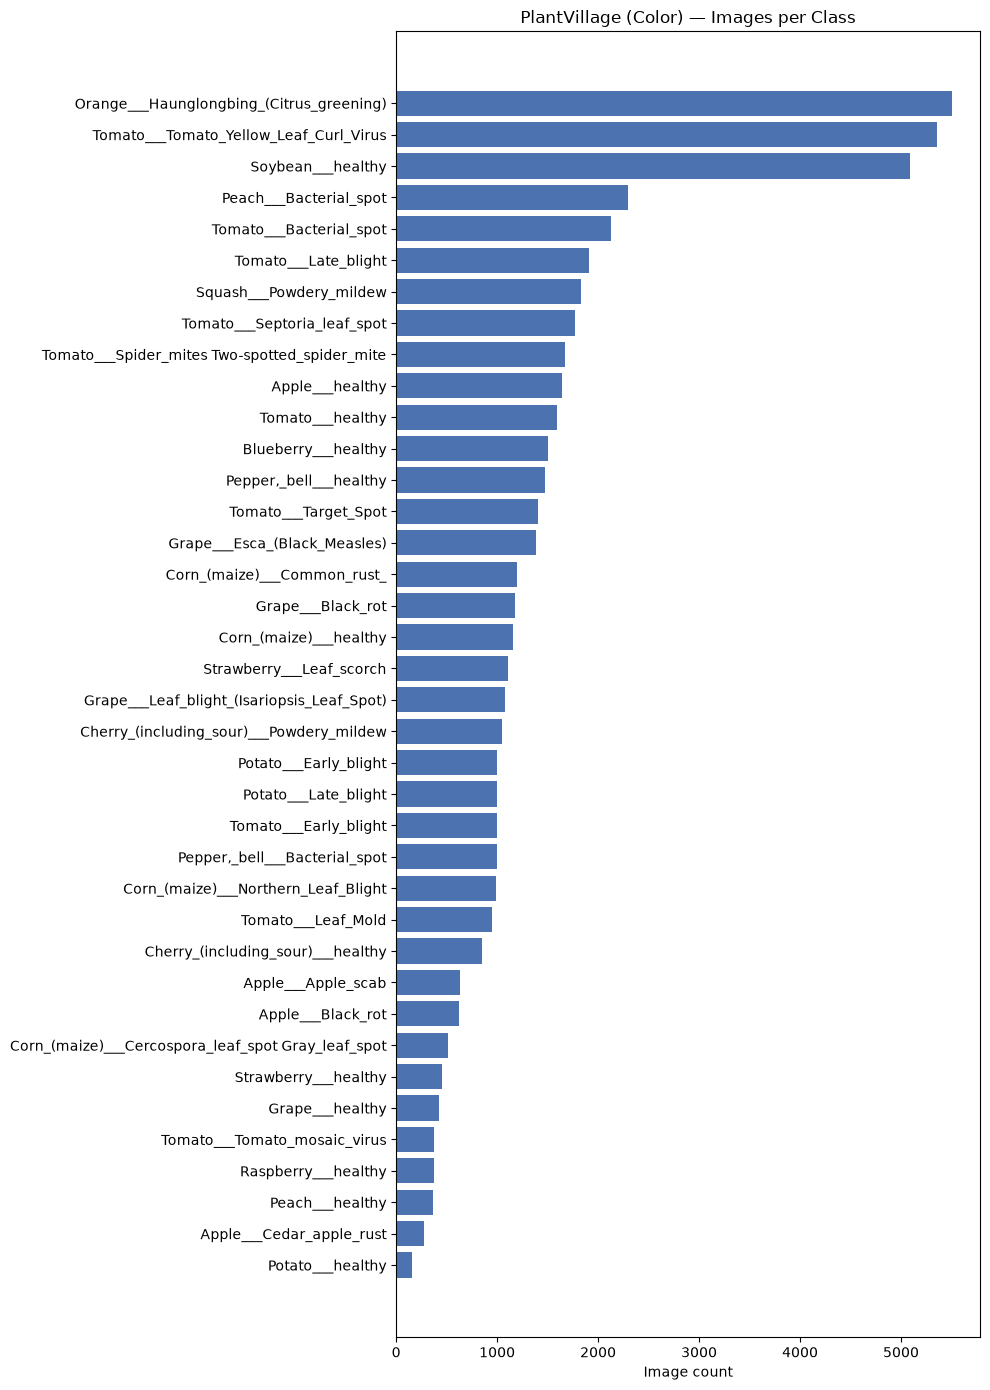

Largest class : Orange___Haunglongbing_(Citrus_greening) (5507 images)
Smallest class: Potato___healthy (152 images)
Imbalance ratio (largest:smallest): 36.2 : 1


In [4]:
class_totals = Counter(r['class_name'] for r in rows)
sorted_classes = sorted(class_totals.items(), key=lambda x: x[1], reverse=True)

names = [c[0] for c in sorted_classes]
counts = [c[1] for c in sorted_classes]

plt.figure(figsize=(10, 14))
plt.barh(names, counts, color='#4C72B0')
plt.xlabel('Image count')
plt.title('PlantVillage (Color) — Images per Class')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'class_distribution.png', dpi=150)
plt.show()

print(f"Largest class : {sorted_classes[0][0]} ({sorted_classes[0][1]} images)")
print(f"Smallest class: {sorted_classes[-1][0]} ({sorted_classes[-1][1]} images)")
print(f"Imbalance ratio (largest:smallest): {sorted_classes[0][1] / sorted_classes[-1][1]:.1f} : 1")


## 3. Image properties check

In [5]:
import random
random.seed(42)

sample_size = min(500, len(rows))
sample_rows = random.sample(rows, sample_size)

sizes = Counter()
modes = Counter()
formats = Counter()
broken_files = []

for r in sample_rows:
    fpath = Path(r['filepath'])
    try:
        with Image.open(fpath) as img:
            sizes[img.size] += 1
            modes[img.mode] += 1
            formats[img.format] += 1
    except Exception as e:
        broken_files.append((str(fpath), str(e)))

print(f"Sampled {sample_size} images\n")
print("Top resolutions:", sizes.most_common(5))
print("Color modes    :", modes.most_common())
print("File formats   :", formats.most_common())
print(f"\nBroken/unreadable files in sample: {len(broken_files)}")
for f, err in broken_files[:10]:
    print(f"  {f}: {err}")


Sampled 500 images

Top resolutions: [((256, 256), 500)]
Color modes    : [('RGB', 500)]
File formats   : [('JPEG', 500)]

Broken/unreadable files in sample: 0


## 4. Visual sanity check — sample grid per class

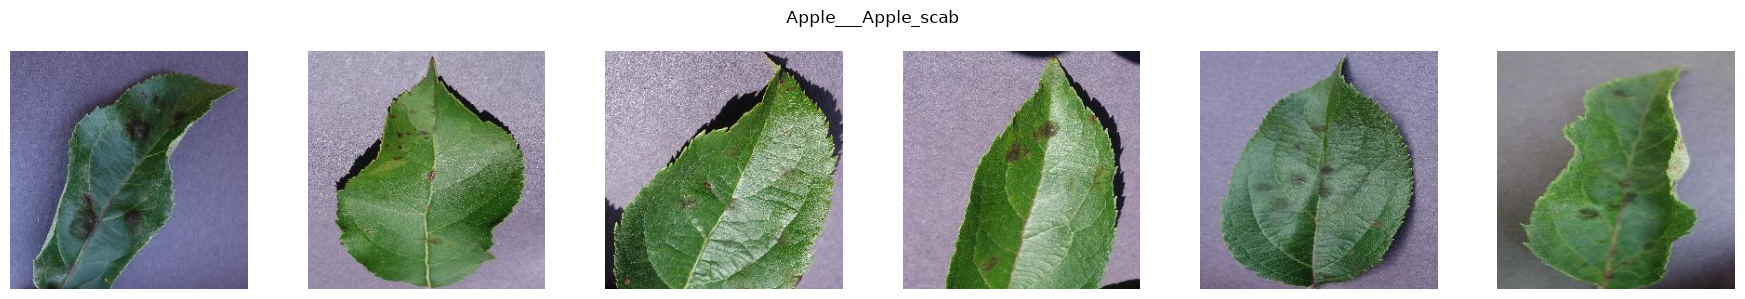

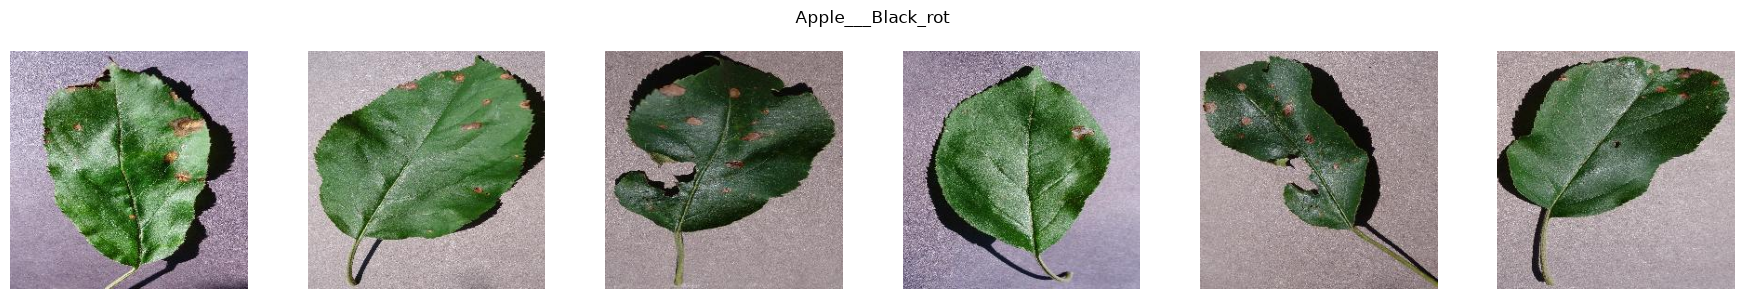

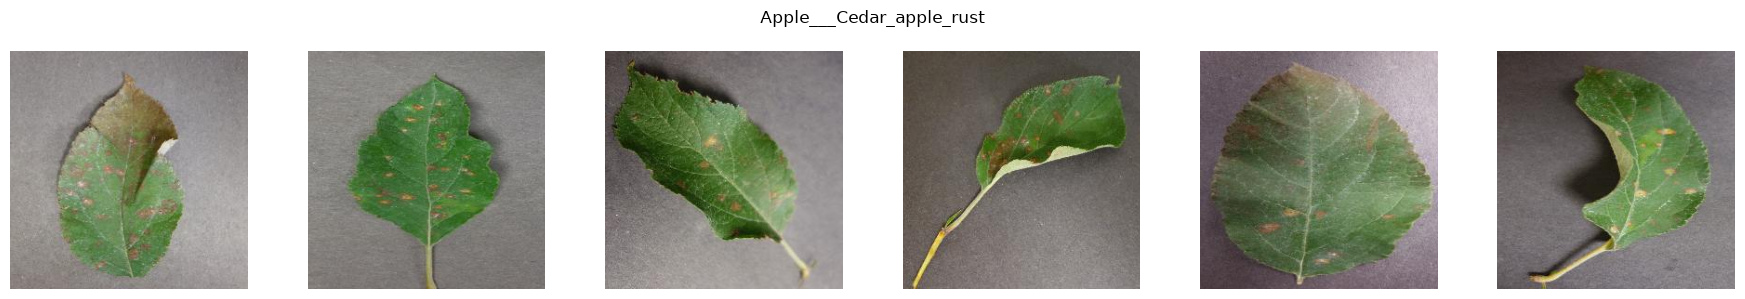

In [6]:
def show_class_samples(class_name, n=6):
    class_rows = [r for r in rows if r['class_name'] == class_name][:n]
    fig, axes = plt.subplots(1, len(class_rows), figsize=(3 * len(class_rows), 3))
    if len(class_rows) == 1:
        axes = [axes]
    for ax, r in zip(axes, class_rows):
        img = Image.open(r['filepath'])
        ax.imshow(img)
        ax.axis('off')
    fig.suptitle(class_name)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'sample_grid_{class_name.replace("/", "_")}.png', dpi=100)
    plt.show()

# Spot-check a few classes — adjust names to match your class_mapping.json exactly
sample_classes = list(class_mapping.keys())[:3]  # first 3 classes as a quick check
for c in sample_classes:
    show_class_samples(c)


## 5. Duplicate / near-duplicate detection

In [7]:
def file_hash(fpath, block_size=65536):
    h = hashlib.md5()
    with open(fpath, 'rb') as f:
        while chunk := f.read(block_size):
            h.update(chunk)
    return h.hexdigest()

# NOTE: hashing all ~54k images takes a few minutes. Sample first to gauge duplicate rate;
# if duplicates are found, re-run on the full set before finalizing splits.
sample_for_hash = random.sample(rows, min(5000, len(rows)))

hash_to_files = defaultdict(list)
for r in sample_for_hash:
    h = file_hash(r['filepath'])
    hash_to_files[h].append(r)

duplicates = {h: files for h, files in hash_to_files.items() if len(files) > 1}
print(f"Sampled {len(sample_for_hash)} images, found {len(duplicates)} duplicate groups")

cross_split_leaks = 0
for h, files in duplicates.items():
    splits_involved = set(f['split'] for f in files)
    if len(splits_involved) > 1:
        cross_split_leaks += 1

print(f"Duplicate groups spanning multiple splits (train/val/test leakage risk): {cross_split_leaks}")


Sampled 5000 images, found 0 duplicate groups
Duplicate groups spanning multiple splits (train/val/test leakage risk): 0
